# Student Name: Isaiah Andres
# Student Number: C00286361

## Introduction:
In this notebook, a K-Means Clustering model will be used in order to identify a given number of clusters in the world that will show up in the columns of log GDP and Ladder Score in the data set, World Happiness Report in 2024 (Link: https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated/data). Three clusters will be picked, potentially splitting the countries plotted out into different groups, of either low, medium, high levels of happiness or Log GDP. 

## Questions:
The questions that may be answered by identifying a three clusters :
##### Can The Happiness of a Country Correlate With Their Log GDP Based On The Clusters They Fall Into?
##### Do Certain World Regions Fall Under Specific Clusters?

## Setting Up Data
In the cell below, the necessary imports are made and the data from the columns are read and placed into a 2d array to act as coordinates for plotting the data.

In [1]:
import numpy as np #Setting up imports
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder 
import matplotlib.patches as ptch 

df = pd.read_csv('World-happiness-report-2024.csv').dropna() #Reading csv files and dropping any values that have empty columns

logGDP = df['Log GDP per capita'].values #Using .values as reading with pandas turns the data into a different format (pandas series) 
happiness = df['Ladder score'].values
plt.style.use('seaborn-v0_8-whitegrid')
coordinates = np.column_stack((logGDP, happiness)) #Using column_stack method to create a 2d array representing coordinates using the Log GDP and Ladder Scorekmeans = KMeans(n_clusters=3) #Using the K-Means clustering model

## Fitting The Model And Finding Clusters
In the cell below, the K-Means model is being set to find three clusters and predicting the clusters based on the coordinates given and the corresponding graph and given silhouette score is output. The colours relating to each cluster shows each cluster represents a low, medium, and high happiness of countries. Seemingly, with three clusters that are approaching the top right it does appears that the Log GDP of a country affects its life satisfaction. The silhouette score ranges between -1 and 1, and is an indicator of how well each data point fits into it's assigned cluster and how far it may be from other clusters.

Training Set Silhoutette Score: 0.47356598757096524


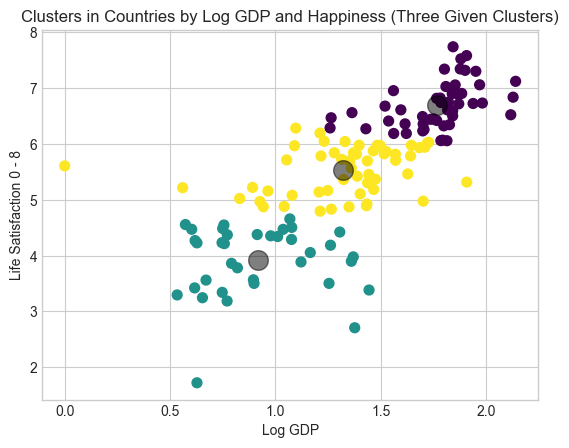

In [2]:
kmeans = KMeans(n_clusters=3) #Setting up a K Means model to look for three clusters
kmeans.fit(coordinates) # Fitting the points
y_kmeans = kmeans.predict(coordinates) # Predicting the clusters

plt.scatter(coordinates[:, 0], coordinates[:, 1], c=y_kmeans, s=50, cmap='viridis') #Scattering plot points

plt.xlabel('Log GDP')
plt.ylabel('Life Satisfaction 0 - 8')
plt.title('Clusters in Countries by Log GDP and Happiness (Three Given Clusters)')

centers = kmeans.cluster_centers_ #Getting cluster centers 
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5); #Plotting cluster centers

silhouette_train_score = silhouette_score(coordinates, y_kmeans)

print("Training Set Silhoutette Score:", silhouette_train_score)

## Trying A Different Number of Clusters
By setting the model to find 4 clusters, it appears that the bottom two clusters are nearly vertical to each other rather than directly being at a greater angle to each other in comparison to the graph above. This information conveys that the Log GDP may not directly have as much impact in a country's happiness in the lower ends of the graph implying that there would be other factors involved such as the perceptions of corruption. As seen in the cell above, the silhouette score is also outputted.

Training Set Silhoutette Score: 0.4603607082369988


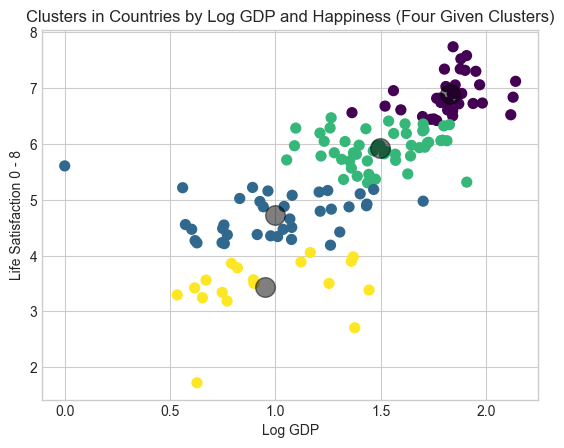

In [7]:
kmeans = KMeans(n_clusters=4) #Setting up a K Means model to look for three clusters
kmeans.fit(coordinates) # Fitting the points
y_kmeans = kmeans.predict(coordinates) # Predicting the clusters

plt.scatter(coordinates[:, 0], coordinates[:, 1], c=y_kmeans, s=50, cmap='viridis') #Scattering plot points

plt.xlabel('Log GDP')
plt.ylabel('Life Satisfaction 0 - 8')
plt.title('Clusters in Countries by Log GDP and Happiness (Four Given Clusters)')

centers = kmeans.cluster_centers_ #Getting cluster centers 
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5); #Plotting cluster centers

silhouette_train_score = silhouette_score(coordinates, y_kmeans)

print("Training Set Silhoutette Score:", silhouette_train_score)

### Finding Cluster Centers In Colour Coded Regions. 
By colour coding the different regions in the graph and finding three cluster centres, the different regions in the data set are shown along side the three cluster centres found based on their Log GDP and Ladder Score. By observing the graph below, the majority of countries within Sub-Saharan Africa and South Asia and some in the Middle East And North Africa are very close to the bottom cluster. Meanwhile, a wide variety of regions are close to both of the middle and top cluster centers. All of Western Europe appears to stay within the top cluster leaving that as the one of the few regions to belong to a cluster alongside South Asia.

['Central and Eastern Europe', 'Commonwealth of Independent States', 'East Asia', 'Latin America and Caribbean', 'Middle East and North Africa', 'North America and ANZ', 'South Asia', 'Southeast Asia', 'Sub-Saharan Africa', 'Western Europe']


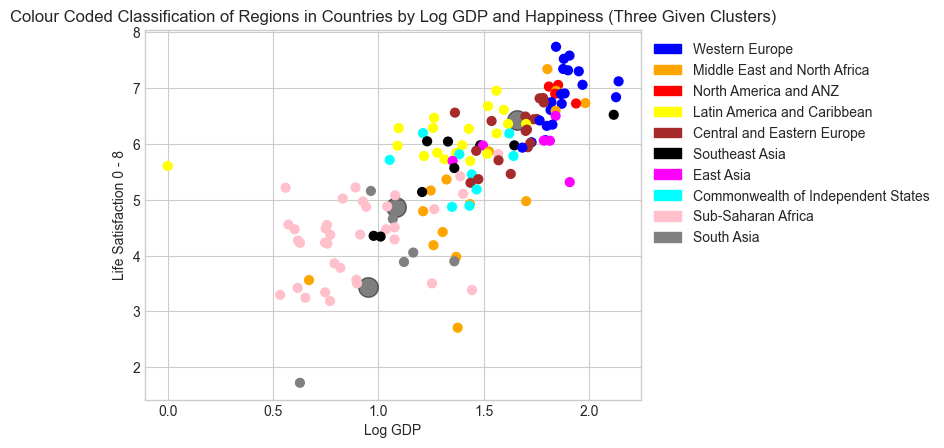

In [9]:
region_colours = { #Assigning colours to each region
    "Western Europe":"Blue",
    "Middle East and North Africa":"Orange",
    "North America and ANZ":"Red",
    "Latin America and Caribbean":"Yellow",
    "Central and Eastern Europe":"Brown",
    "Southeast Asia":"Black",
    "East Asia":"Magenta",
    "Commonwealth of Independent States":"Cyan",
    "Sub-Saharan Africa":"Pink",
    "South Asia":"Grey"
}

le = LabelEncoder()
numerical_regions = le.fit_transform(df['Regional indicator'])  #Converting categorical data (regions) to numerical format (Regions are listed alphabetically and then indexed)

regions = list(le.classes_) #.classes holds the label for each category 
print(regions)

label_to_colour = {i: region_colours[region] for i, region in enumerate(regions)} #Assigning colours defined before to each region, enumerate(regions) gives an index for each region to index through

point_colours = [label_to_colour[i] for i in numerical_regions]

kmeans = KMeans(n_clusters=3) #Setting up a K Means model to look for three clusters
kmeans.fit(coordinates) # Fitting the points
y_kmeans = kmeans.predict(coordinates) # Predicting the clusters

centers = kmeans.cluster_centers_ #Getting cluster centers 
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5); #Plotting cluster centers
# Plot scatter
plt.scatter(coordinates[:, 0], coordinates[:, 1], c=point_colours, s=40)

plt.xlabel('Log GDP')
plt.ylabel('Life Satisfaction 0 - 8')
plt.title('Colour Coded Classification of Regions in Countries by Log GDP and Happiness (Three Given Clusters)')

def add_legend():
    region_patches=[
        ptch.Patch(color="Blue",label="Western Europe"),
        ptch.Patch(color="Orange",label="Middle East and North Africa"),
        ptch.Patch(color="Red",label="North America and ANZ"),
        ptch.Patch(color="Yellow",label="Latin America and Caribbean"),
        ptch.Patch(color="Brown",label="Central and Eastern Europe"),
        ptch.Patch(color="Black",label="Southeast Asia"),
        ptch.Patch(color="Magenta",label="East Asia"),
        ptch.Patch(color="Cyan",label="Commonwealth of Independent States"),
        ptch.Patch(color="Pink",label="Sub-Saharan Africa"),
        ptch.Patch(color="Grey",label="South Asia")]
    
    plt.legend(handles=region_patches,bbox_to_anchor=(1,1))
add_legend()

## Evaluating The Model
When splitting the data into training and testing sets, the test predictions for cluster centers and the clusters in general that are made are the exact same as the ones fitted using data that was never split to begin with, due to the fact that the model is unsupervised if set up to look for the same number of clusters meaning that the silhouette score provided is a better indicator of the model's effectiveness.

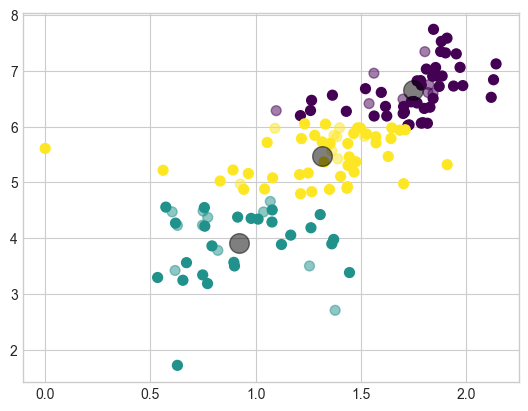

In [5]:
#K-Means is an unsupervised model, so no point in test sets if it's not learning?
X_train, X_test, y_train, y_test = train_test_split(logGDP, happiness, test_size=0.2, random_state=42) # Split data into 80% training and 20% test set

kmeans = KMeans(n_clusters=3) #Using the K-Means clustering model
kmeans.fit(coordinates) #Fitting the coordinates with the model
coordinatesTrainSet = np.column_stack((X_train, y_train)) #Using column_stack method to create a 2d array representing coordinates using the Log GDP and Ladder Score
y_kmeans_train = kmeans.predict(coordinatesTrainSet) #Predicting the clusters of the coordinates

coordinatesTestSet = np.column_stack((X_test, y_test)) #Using column_stack method to create a 2d array representing coordinates using the Log GDP and Ladder Score
y_kmeans_test = kmeans.predict(coordinatesTestSet) #Predicting the clusters of the coordinates

plt.scatter(coordinatesTrainSet[:, 0], coordinatesTrainSet[:, 1], c=y_kmeans_train, s=50, cmap='viridis') #Scattering the points

plt.scatter(coordinatesTestSet[:, 0], coordinatesTestSet[:, 1], c=y_kmeans_test, s=50, cmap='viridis', alpha=0.5) #Scattering the points

centers = kmeans.cluster_centers_ #Finding the centers and plotting them
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

## Predicting On All Available Feature Sets
The cell below plots countries based on their Ladder Score and Log GDP however the K-Means model itself is trained on all available feature sets in the data set. These features are Log GDP per capita, Ladder score,

Social support (The national average of binary responses(either 0 or 1 representing No/Yes) to the question about having relatives or friends to count on in times of trouble.), Healthy life expectancy ( The average number of years a newborn infant would live in good health, based on mortality rates and life expectancy at different ages.),

Freedom to make life choices (The national average of responses to the question about satisfaction with freedom to choose what to do with one's life),

Generosity (The residual of regressing the national average of responses to the question about donating money to charity on GDP per capita), 

Perceptions of corruption (The national average of survey responses to questions about the perceived extent of corruption in the government and businesses),

Dystopia + residual ( Dystopia is an imaginary country with the world’s least-happy people, used as a benchmark for comparison. The dystopia + residual score is a combination of the Dystopia score and the unexplained residual for each country, ensuring that the combined score is always positive. Each of these factors contributes to the overall happiness score, but the Dystopia + residual value is a benchmark that ensures no country has a lower score than the hypothetical Dystopia).

The descriptions for the remaining features are taken from the data set content descriptions.

Training Set Silhoutette Score: 0.4732983045395376


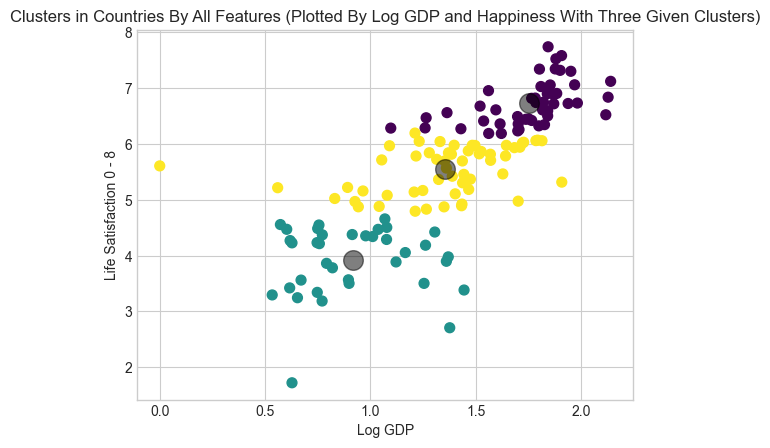

In [8]:
df = pd.read_csv('World-happiness-report-2024.csv').dropna() #Reading csv files and dropping any values that have empty columns

plt.style.use('seaborn-v0_8-whitegrid')
all_features = df[['Log GDP per capita', 'Ladder score', 'Social support', 'Healthy life expectancy',
                   'Freedom to make life choices', 'Generosity','Perceptions of corruption','Dystopia + residual']].values #Using column_stack method to create a 2d array representing coordinates using the Log GDP and Ladder Scorekmeans = KMeans(n_clusters=3) #Using the K-Means clustering model

kmeans = KMeans(n_clusters=3) #Setting up a K Means model to look for three clusters
kmeans.fit(all_features) # Fitting the points
y_kmeans = kmeans.predict(all_features) # Predicting the clusters

plt.scatter(coordinates[:, 0], coordinates[:, 1], c=y_kmeans, s=50, cmap='viridis') #Scattering plot points

plt.xlabel('Log GDP')
plt.ylabel('Life Satisfaction 0 - 8')
plt.title('Clusters in Countries By All Features (Plotted By Log GDP and Happiness With Three Given Clusters)')

centers = kmeans.cluster_centers_ #Getting cluster centers 
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5); #Plotting cluster centers

silhouette_train_score = silhouette_score(coordinates, y_kmeans)

print("Training Set Silhoutette Score:", silhouette_train_score)

In the above graph, it appears that the clusters still stay similar to the graphs involving just the Log GDP and the Ladder Score for happiness, as the clusters still go toward the top right. This may mean that despite these clusters appearing in very similar areas when compared to clusters found when predicting based on Log GDP and Happiness, how each country is doing based on the additional features may also correlate to their cluster e.g countries in the highest cluster tend to do very well in terms of social support or freedom to make life choices.

## Conclusion
In conclusion, given three clusters, the cluster centers predicted by the model appear to move diagonally to the top right which may indicate that the Log GDP of a country has at least some effect to a country's happiness. However given four clusters, The prediction show that the Log GDP may not directly have as much impact in a country's happiness in the lower ends of the graph given that the second cluster from the bottom is nearly vertical to the bottom cluster, showing that despite having similar Log GDPs, some countries still have higher happiness on the ladder score. When predicting based on all available features however, the clusters appear to be nearly the exact same when predicting on just Log GDP and Ladder Score for happiness. This may imply that the countries in the higher cluster may just be doing better in terms of other features such as perceptions of corruption in comparison to countries in the clusters below. Regions do also tend to appear in certain clusters with the majority of Sub-Saharan Africa ending up around the lowest cluster alongside South Asia even when predicting on all feature sets. 